In [10]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score,confusion_matrix,precision_score,recall_score,roc_curve,auc)
import matplotlib.pyplot as plt 
import numpy as np

In [11]:
file_path= "data (1).csv"
data = pd.read_csv(file_path)
X= data.drop(columns=['fail'])
y= data['fail']

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [13]:
nb_model = GaussianNB()

nb_model.fit(X_train,y_train)

y_pred = nb_model.predict(X_test)
y_pred_prob = nb_model.predict_proba(X_test)[:,1]

In [14]:
accuracy=accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)
precision=precision_score(y_test,y_pred)
sensitivity = recall_score(y_test,y_pred)

In [15]:
TN = conf_matrix[0,0]
FP = conf_matrix[0,1]
specificity = TN / (TN+FP)
standard_error = np.sqrt((accuracy*(1-accuracy))/len(y_test))


fpr,tpr,_=roc_curve(y_test,y_pred_prob)
roc_auc = auc(fpr, tpr)

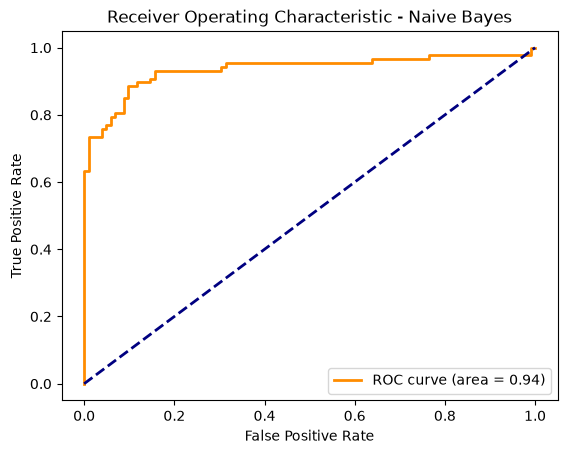

In [16]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Naive Bayes')
plt.legend(loc="lower right")
plt.show()


In [20]:
print("Predictions:",y_pred)
print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy * 100:.7f}%")
print("Confusion Matrix:\n", conf_matrix)
print("Standard Error:", standard_error)
print("Precision:", precision)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("AUC:", roc_auc)



Predictions: [1 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0 1 1 0
 0 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 1 1 1 1 1
 0 0 1 0 0 1 1 0 1 1 1 0 0 0 1 1 0 0 0 0 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1
 0 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 1 1 0 1 0 0 1 0 1 1 1 1 1
 1 0 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 0 1
 0 0 0 1]
Accuracy: 0.873015873015873
Accuracy: 87.3015873%
Confusion Matrix:
 [[86 16]
 [ 8 79]]
Standard Error: 0.024218926360691187
Precision: 0.8315789473684211
Sensitivity (Recall): 0.9080459770114943
Specificity: 0.8431372549019608
AUC: 0.9353166553977912
